In [1]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

In [2]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

**Artificial ground-truth mask**

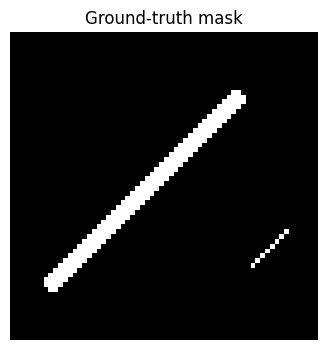

Foreground pixels: 210
Background pixels: 3886


In [3]:
HEIGHT = 64
WIDTH = 64

ground_truth = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)

cv2.line(ground_truth, (8, 52), (47, 13), color=1, thickness=2)
cv2.line(ground_truth, (50, 48), (57, 41), color=1, thickness=1)

plt.figure(figsize=(4, 4))
plt.imshow(ground_truth, cmap="gray", vmin=0, vmax=1,)

plt.title("Ground-truth mask")
plt.axis("off")
plt.show()

print("Foreground pixels:",ground_truth.sum())
print("Background pixels:",ground_truth.size - ground_truth.sum())

**5 types of prediction**

In [4]:
def shift_mask(mask, dx=0, dy=0):
    transform = np.float32([
        [1, 0, dx],
        [0, 1, dy]
    ])
    return cv2.warpAffine(
        mask, transform,
        (mask.shape[1], mask.shape[0]),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

In [5]:
perfect_prediction = ground_truth.copy()
empty_prediction = np.zeros_like(ground_truth)
shifted_prediction = shift_mask(ground_truth, dx=3)

tiny_crack_missed = ground_truth.copy()
tiny_crack_missed[38:51, 48:60] = 0

background_false_positive = ground_truth.copy()
background_false_positive[5:18, 45:59] = 1

predictions = {
    "perfect": perfect_prediction,
    "empty": empty_prediction,
    "shifted": shifted_prediction,
    "tiny_missed": tiny_crack_missed,
    "background_fp": background_false_positive
}

**Normalized polygon to raster mask**

In [11]:
polygon_normalized = np.array([
        [0.10, 0.75],
        [0.18, 0.68],
        [0.32, 0.60],
        [0.48, 0.42],
        [0.65, 0.28],
        [0.69, 0.32],
        [0.52, 0.48],
        [0.35, 0.66],
        [0.20, 0.73],
        [0.12, 0.79]
],dtype=np.float32)

polygon_pixels = np.column_stack([
    polygon_normalized[:, 0] * (WIDTH - 1),
    polygon_normalized[:, 1] * (HEIGHT - 1)
])

polygon_pixels = polygon_pixels.round().astype(np.int32)
polygon_mask = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)

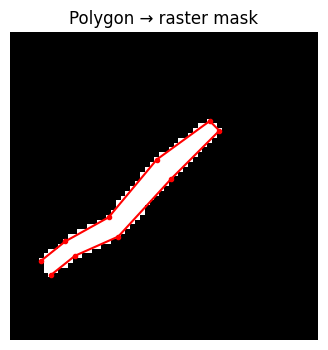

In [15]:
cv2.fillPoly(polygon_mask, [polygon_pixels], color=1)

plt.figure(figsize=(4, 4))
plt.imshow(polygon_mask, cmap="gray")
plt.plot(polygon_pixels[:, 0], polygon_pixels[:, 1], "r.-")
plt.title("Polygon → raster mask")
plt.axis("off")
plt.show()